# 01-Foundations

[![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)

# 22-Computational-Complexity



[![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE)

[![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)

In [1]:
# --- Global Notebook Setup ---
import os
import sys
import math
import time
import random
import timeit
import json
import textwrap
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Apply the standard course style for all plots
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 12,
        "lines.linewidth": 2,
        "lines.markersize": 6,
    }
)
%config InlineBackend.figure_format = 'retina'  # High-res plots

warnings.filterwarnings("ignore", category=FutureWarning)
print("Environment initialized.")

Environment initialized.


### Table of Contents
1. [The Lens: Why Algorithm Speed Matters](#The-Lens:-Why-Algorithm-Speed-Matters)
2. [Big-O Notation: Characterizing Scalability](#Big-O-Notation:-Characterizing-Scalability)
3. [Empirical Verification with `timeit`](#Empirical-Verification-with-timeit)
4. [The Curse of Dimensionality](#The-Curse-of-Dimensionality)
5. [Complexity in Economic Applications](#Complexity-in-Economic-Applications)
    - [Solving Linear Systems](#Solving-Linear-Systems)
    - [Maximum Likelihood Estimation](#Maximum-Likelihood-Estimation)
    - [Dynamic Programming](#Dynamic-Programming)
6. [Summary](#Summary)
7. [Exercises](#Exercises)

# The Lens

As economic models become more complex—incorporating heterogeneous agents, high-dimensional state spaces, or massive datasets—the question of whether they can be solved in a reasonable amount of time becomes critical. It is not enough for an algorithm to be correct; it must also be feasible.

**Computational complexity theory** is the branch of computer science that studies the resources (primarily time and memory) required to run an algorithm. For economists, a basic understanding of complexity is essential for recognizing which problems are feasible to solve, for choosing the right algorithm for the job, and for understanding the trade-offs inherent in model design. It provides the vocabulary to explain why a model with 2 state variables runs in seconds, but adding a third makes it take hours.

### Big-O Notation: Characterizing Scalability

**Big-O notation** is the standard way to describe an algorithm's efficiency in the worst-case scenario. It characterizes how the runtime or memory usage of an algorithm grows as the size of the input, $n$, grows. It ignores constant factors and lower-order terms, focusing on the dominant term that determines the algorithm's scalability.

**Common Complexity Classes:**
- **O(1) - Constant Time:** The runtime is independent of the input size. (e.g., accessing an element in an array by its index).
- **O(log n) - Logarithmic Time:** The runtime grows logarithmically with the input size. Extremely efficient. (e.g., binary search).
- **O(n) - Linear Time:** The runtime grows linearly with the input size. (e.g., finding the maximum value in an unsorted list).
- **O(n log n) - Log-Linear Time:** The 'gold standard' for sorting algorithms. (e.g., Merge Sort, Quicksort).
- **O(n^2) - Quadratic Time:** The runtime grows with the square of the input size. Becomes slow quickly. (e.g., nested loops, naive matrix multiplication).
- **O(2^n) - Exponential Time:** The runtime doubles with each additional element in the input. Becomes intractable for even moderately sized inputs. (e.g., traveling salesman problem via brute force).
- **O(n!) - Factorial Time:** Even worse than exponential. Unfeasible for all but the smallest inputs.

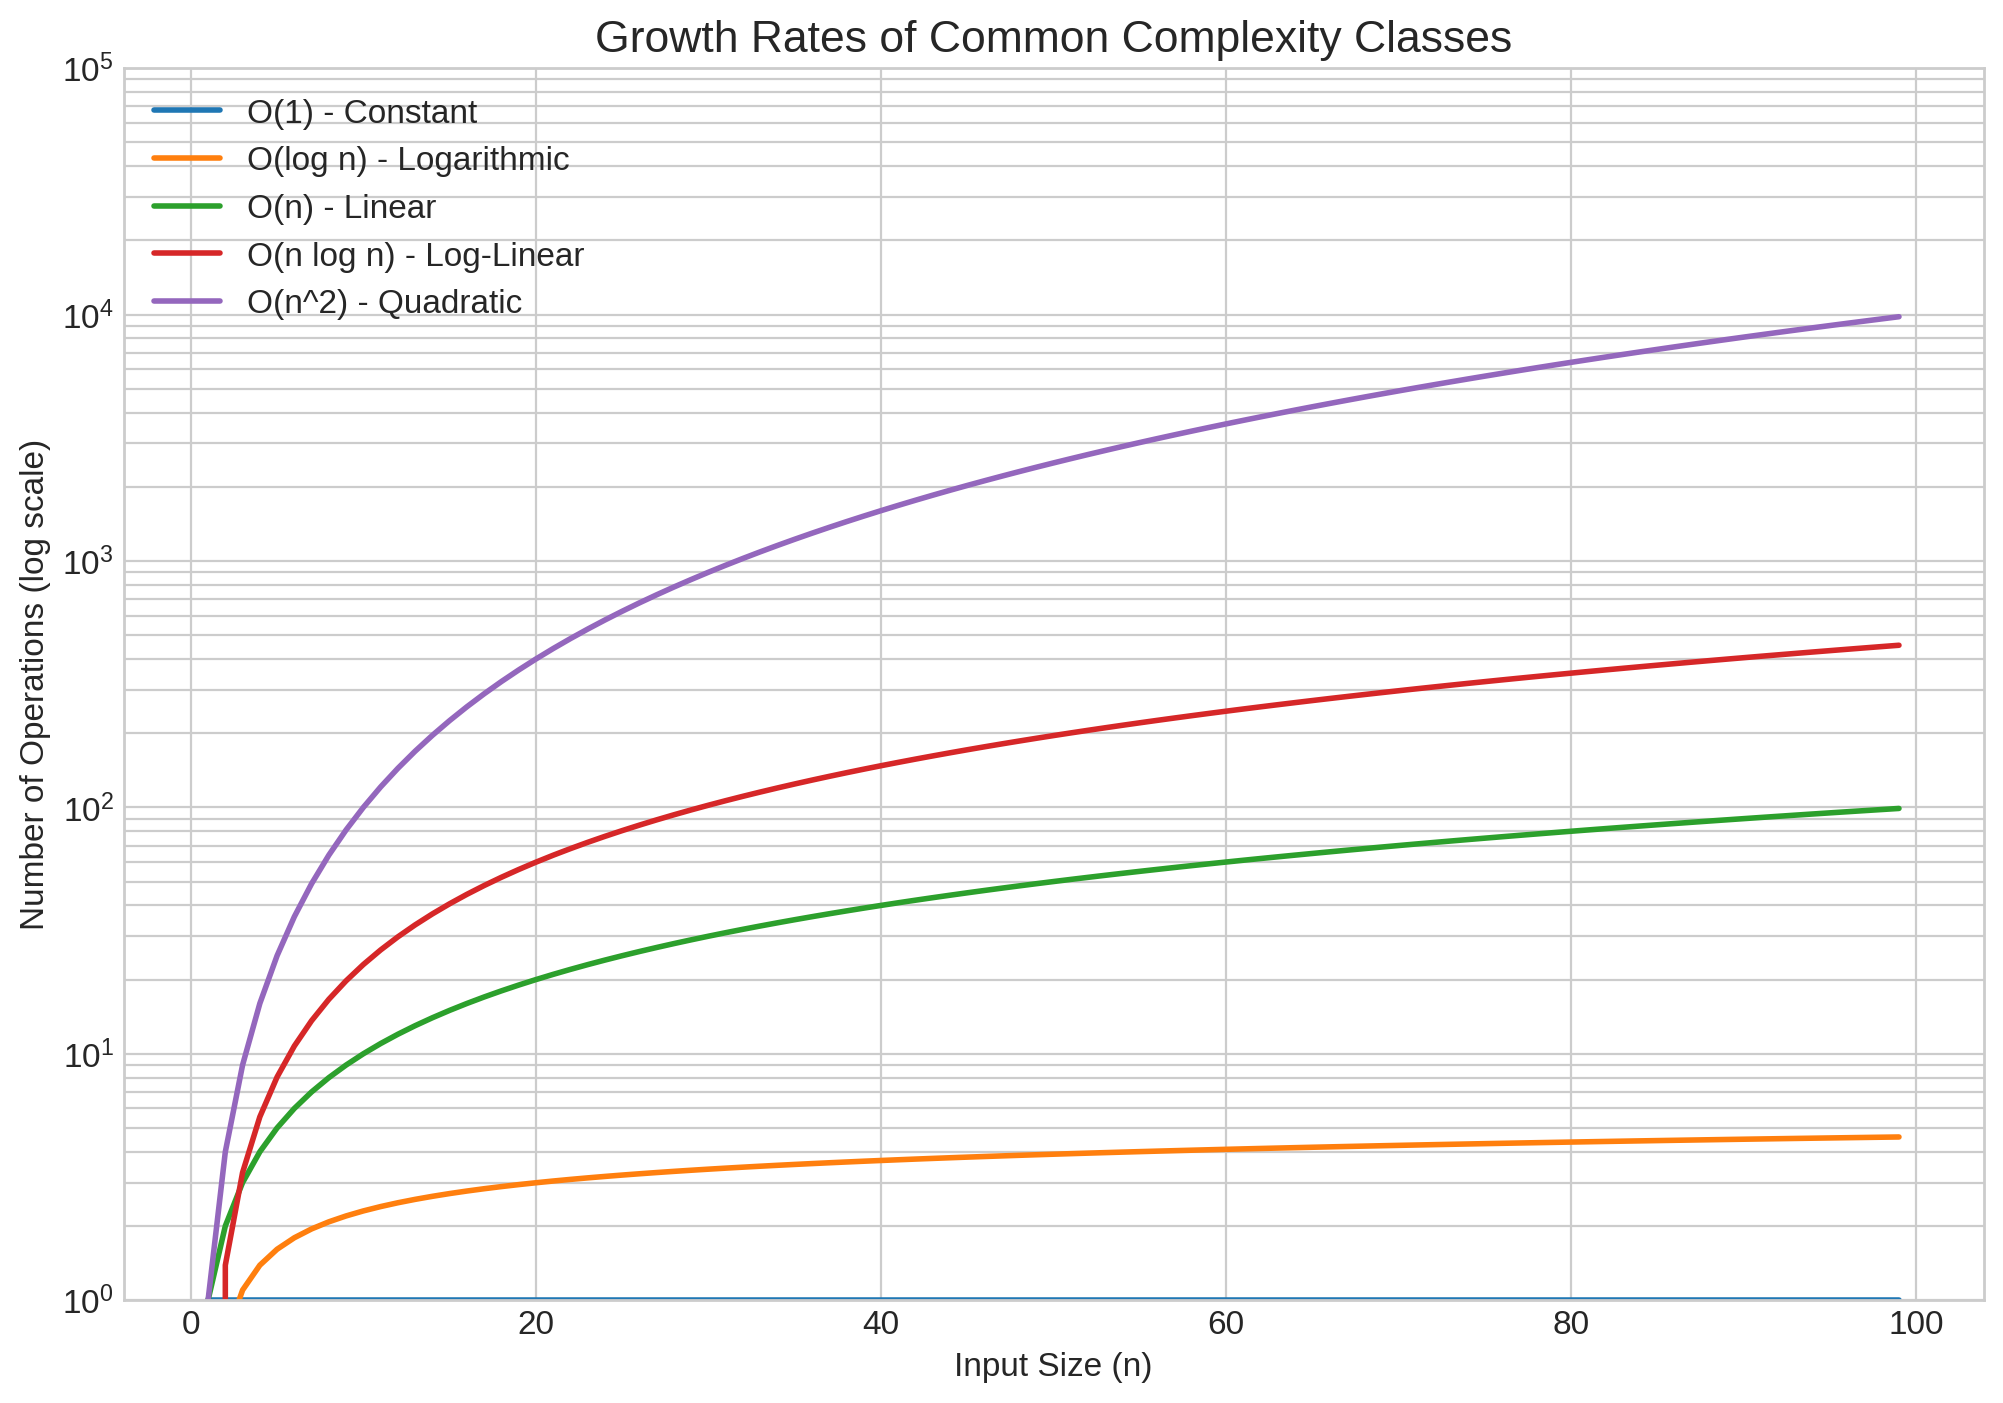

In [2]:
n = np.arange(1, 100)
plt.figure(figsize=(12, 8))
plt.plot(n, np.ones_like(n), label="O(1) - Constant")
plt.plot(n, np.log(n), label="O(log n) - Logarithmic")
plt.plot(n, n, label="O(n) - Linear")
plt.plot(n, n * np.log(n), label="O(n log n) - Log-Linear")
plt.plot(n, n**2, label="O(n^2) - Quadratic")
plt.title("Growth Rates of Common Complexity Classes")
plt.xlabel("Input Size (n)")
plt.ylabel("Number of Operations (log scale)")
plt.yscale("log")
plt.legend()
plt.ylim(1, 10**5)
plt.grid(True, which="both", ls="-")
plt.show()

### Empirical Verification with `timeit`

We can empirically verify the complexity of algorithms using Python's `timeit` module. Let's compare finding an item in a list (O(n)) vs. a set (O(1)).

Size 1000: List=0.00232s, Set=0.00001s
Size 10000: List=0.01834s, Set=0.00001s
Size 100000: List=0.17663s, Set=0.00001s


Size 1000000: List=1.77933s, Set=0.00001s


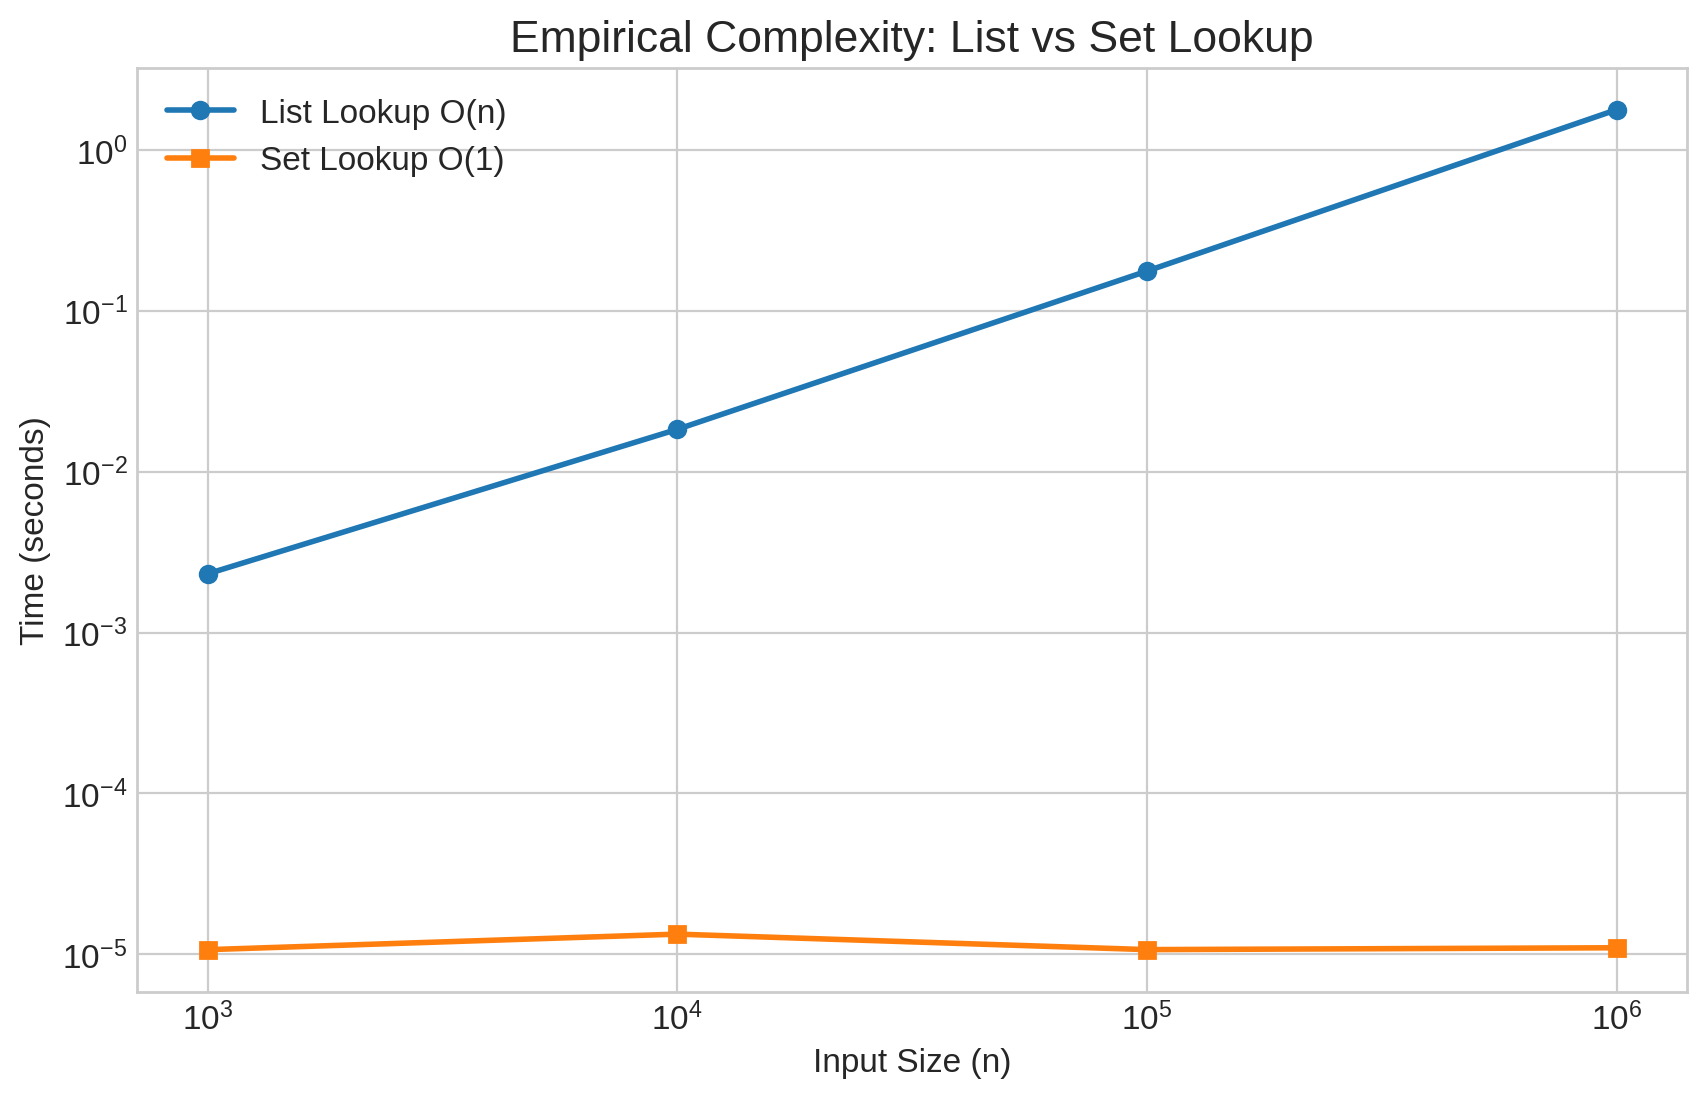

In [3]:
sizes = [1000, 10000, 100000, 1000000]
list_times = []
set_times = []

for size in sizes:
    # Generate data
    data_list = list(range(size))
    data_set = set(data_list)

    # Test Case: Find the last element (Worst case for list)
    target = size - 1

    # Time List lookup
    t_list = timeit.timeit(lambda: target in data_list, number=100)
    list_times.append(t_list)

    # Time Set lookup
    t_set = timeit.timeit(lambda: target in data_set, number=100)
    set_times.append(t_set)

    print(f"Size {size}: List={t_list:.5f}s, Set={t_set:.5f}s")

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(sizes, list_times, "o-", label="List Lookup O(n)")
plt.plot(sizes, set_times, "s-", label="Set Lookup O(1)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input Size (n)")
plt.ylabel("Time (seconds)")
plt.title("Empirical Complexity: List vs Set Lookup")
plt.legend()
plt.show()

### The Curse of Dimensionality

The **curse of dimensionality**, a term coined by Richard Bellman (of the Bellman equation), refers to the exponential explosion in the volume of a space as its number of dimensions increases. This has profound consequences for computational economics, especially in dynamic programming.

Imagine solving a household's consumption-saving problem where the state is their current wealth. If we discretize wealth into a grid of 100 points, we must solve the Bellman equation at each point. Now, suppose the household has two assets (e.g., liquid and illiquid). To maintain the same resolution for each asset, our state space grid now has $100 \times 100 = 10,000$ points. With three assets, it's $100^3 = 1,000,000$ points. The size of the problem grows exponentially with the number of state variables.

This is why so many models are simplified to have only one or two state variables. Overcoming the curse of dimensionality is a major motivation for developing more advanced numerical methods, such as sparse grids, adaptive grids, and machine learning-based function approximation.

### Complexity in Economic Applications

#### Solving Linear Systems
Solving a system of $n$ linear equations, $Ax=b$, is fundamental to econometrics (OLS) and general equilibrium models. The standard algorithm, Gaussian elimination, has a complexity of **O(n^3)**. This means that doubling the number of equations increases the solution time by a factor of eight.

#### Maximum Likelihood Estimation
The complexity of MLE depends on the optimization algorithm used. For a simple logit model with $N$ observations and $k$ features, each iteration of a Newton-like optimizer often requires computing the Hessian, which can be **O(Nk^2)**. This informs the choice of optimizer for large datasets.

#### Dynamic Programming
As discussed, grid-based solutions to DP problems suffer from the curse of dimensionality. If there are $d$ state variables and we use $m$ grid points for each, the complexity is **O(m^d)**, which is exponential in the number of dimensions.

# Summary

Understanding computational complexity allows economists to:
- **Predict Feasibility:** Estimate how long a model will take to run before writing the code.
- **Choose Algorithms:** Select the most appropriate method for the data size (e.g., avoiding O(n^2) algorithms for large datasets).
- **Design Models:** Make informed trade-offs between model richness (dimensionality) and computational tractability.

It is the theoretical framework that guides practical coding decisions.

### Exercises

1.  **Complexity Analysis:** For each of the following scenarios, identify the Big-O complexity class:
    a. Looking up a price in a Python dictionary of $n$ stocks.
    b. Calculating the sample mean of a list of $n$ wages.
    c. Finding the closest pair of points in a set of $n$ locations using a brute-force approach (comparing every pair).

2.  **The Curse in Practice:** Calculate the total number of grid points required to solve a dynamic model with:
    a. 1 state variable with 50 grid points.
    b. 3 state variables, each with 50 grid points.
    c. 6 state variables, each with 50 grid points.
    Assuming each point takes 1 millisecond to solve, how long would each model take to run?